# MSCS 634 — Project Deliverable 3
## Classification, Clustering, and Pattern Mining

**Dataset:** Clickstream Data for Online Shopping (UCI ML Repository, ID 553)  
**Group Member:** Mohammed Sajjad Mohammed Arif Ansari, Hoai Nam Tran  
**Course:** Advanced Big Data and Data Mining

---

## 1. Overview

Deliverable 2 asked which *products* attract attention. This deliverable moves to
*visitors* and asks three questions:

- **Part A — Classification.** Can We tell from a visitor's first two clicks whether
  they'll browse deeply? *(Decision Tree, k-NN, Naive Bayes)*
- **Part B — Clustering.** What types of shopping session exist? *(K-Means)*
- **Part C — Pattern mining.** Which products get browsed together? *(Apriori)*

Part A is framed around the **first two clicks** deliberately. Predicting engagement
from a whole session is circular — a long session is deep almost by definition. Using
only the opening clicks makes it a real prediction problem, and a practically useful
one: a retailer could act on it while the visitor is still on the site.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             accuracy_score, f1_score, classification_report, silhouette_score)
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

clicks = pd.read_csv("clickstream_clean_click_level.csv").sort_values(["session_id", "click_order"])
sessions = pd.read_csv("clickstream_clean_session_level.csv")

print(f"Clicks:   {clicks.shape[0]:,}")
print(f"Sessions: {sessions.shape[0]:,}")

Clicks:   165,474
Sessions: 24,026


# Part A — Classification

## 2. Building the prediction task

**Target:** did the session reach page 3 or deeper? (`deep` vs `shallow`)

**Features:** taken from the **first two clicks only**, what the visitor landed on,
its price, its colour, where the photo sat, plus context like country and weekday.

Sessions with only one click are excluded, since there is no second click to observe.
That leaves 18,984 of 24,026 sessions.

In [2]:
# Features from the opening two clicks
early = clicks[clicks["click_order"] <= 2]

features = early.groupby("session_id").agg(
    first_category=("main_category", "first"),
    first_colour=("colour", "first"),
    first_location=("photo_location", "first"),
    first_photo=("model_photography", "first"),
    first_price=("price", "first"),
    mean_early_price=("price", "mean"),
    n_early_categories=("main_category", "nunique"),
    country_group=("country_group", "first"),
    weekday=("weekday", "first"),
    month=("month", "first"),
).reset_index()

# Target from the whole session
depth = clicks.groupby("session_id")["page_number"].max().rename("max_page").reset_index()
sizes = clicks.groupby("session_id").size()

data = features.merge(depth, on="session_id")
data = data[data["session_id"].isin(sizes[sizes >= 2].index)].copy()
data["deep"] = (data["max_page"] >= 3).astype(int)

print(f"Sessions usable: {len(data):,} of {sizes.shape[0]:,}")
print(f"\nClass balance:")
print(data["deep"].value_counts().rename({0: "shallow", 1: "deep"}).to_string())
print(f"\nDeep rate: {100 * data['deep'].mean():.1f}%")
print(f"Majority-class baseline accuracy: {max(data['deep'].mean(), 1 - data['deep'].mean()):.4f}")

Sessions usable: 18,984 of 24,026

Class balance:
deep
shallow    10320
deep        8664

Deep rate: 45.6%
Majority-class baseline accuracy: 0.5436


In [3]:
CAT = ["first_category", "first_colour", "first_location",
       "first_photo", "country_group", "weekday"]
NUM = ["first_price", "mean_early_price", "n_early_categories", "month"]

X = data[CAT + NUM]
y = data["deep"]

def build(model):
    """Identical preprocessing for every classifier so comparisons are fair."""
    return Pipeline([
        ("prep", ColumnTransformer([
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
            ("scale", StandardScaler(), NUM),
        ])),
        ("model", model),
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")
print(f"Stratified, so both keep a {100 * y_train.mean():.1f}% deep rate.")

Train: 15,187   Test: 3,797
Stratified, so both keep a 45.6% deep rate.


## 3. Three classifiers

`stratify=y` on the split, and `StratifiedKFold` for cross-validation, both keep the
class proportions constant. Without this, a fold could end up with an unrepresentative
mix and the scores would wobble for reasons unrelated to the models.

In [4]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"
pd.set_option("display.notebook_repr_html", False)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "k-NN (k=25)": KNeighborsClassifier(n_neighbors=25),
    "Naive Bayes": GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for name, model in models.items():
    pipe = build(model)
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    f1 = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
    roc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    rows.append({"Model": name, "Accuracy": acc.mean(), "F1": f1.mean(),
                 "ROC-AUC": roc.mean(), "Acc std": acc.std()})
    print(f"{name:<16} accuracy={acc.mean():.4f}  F1={f1.mean():.4f}  AUC={roc.mean():.4f}")

baseline_results = pd.DataFrame(rows).set_index("Model").round(4)
print()
baseline_results

Decision Tree    accuracy=0.6401  F1=0.5449  AUC=0.6743
k-NN (k=25)      accuracy=0.6286  F1=0.5387  AUC=0.6706
Naive Bayes      accuracy=0.5959  F1=0.4790  AUC=0.6288



               Accuracy      F1  ROC-AUC  Acc std
Model                                            
Decision Tree    0.6401  0.5449   0.6743   0.0058
k-NN (k=25)      0.6286  0.5387   0.6706   0.0062
Naive Bayes      0.5959  0.4790   0.6288   0.0049

## 4. Hyperparameter tuning

The Decision Tree is tuned with `GridSearchCV`, which fits every combination of the
listed parameters under cross-validation and keeps the best.

**Why these parameters:**

- **`max_depth`** — the main control on overfitting. A deep tree can memorise
  individual sessions; a shallow one may miss real structure.
- **`min_samples_leaf`** — forces each leaf to cover a minimum number of sessions, so
  the tree cannot build rules from a handful of examples.
- **`criterion`** — gini and entropy measure split quality differently; usually
  similar in practice, included to confirm rather than assume.

**Scoring on F1 rather than accuracy**, because F1 balances precision and recall.
With a 46/54 split, accuracy can be inflated by favouring the majority class.

In [5]:
param_grid = {
    "model__max_depth": [3, 5, 7, 10, 15, None],
    "model__min_samples_leaf": [1, 10, 50, 100],
    "model__criterion": ["gini", "entropy"],
}

grid = GridSearchCV(
    build(DecisionTreeClassifier(random_state=42)),
    param_grid, cv=cv, scoring="f1", n_jobs=1, verbose=0,
)
grid.fit(X_train, y_train)

print("Best parameters:")
for k, v in grid.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nBest cross-validated F1: {grid.best_score_:.4f}")
print(f"Untuned Decision Tree F1: {baseline_results.loc['Decision Tree', 'F1']:.4f}")

tuned_tree = grid.best_estimator_

Best parameters:
  criterion: entropy
  max_depth: 10
  min_samples_leaf: 10

Best cross-validated F1: 0.5692
Untuned Decision Tree F1: 0.5449


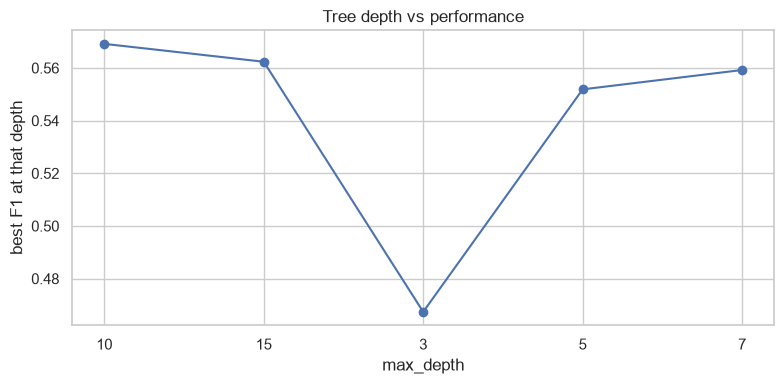

  max_depth  best_F1
0        10   0.5692
1        15   0.5624
2         3   0.4674
3         5   0.5519
4         7   0.5592

In [6]:
# How does performance vary with tree depth?
cv_df = pd.DataFrame(grid.cv_results_)
depth_effect = (cv_df.groupby(cv_df["param_model__max_depth"].astype(str))["mean_test_score"]
                     .max().reset_index())
depth_effect.columns = ["max_depth", "best_F1"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depth_effect["max_depth"], depth_effect["best_F1"], "o-")
ax.set_xlabel("max_depth"); ax.set_ylabel("best F1 at that depth")
ax.set_title("Tree depth vs performance")
plt.tight_layout(); plt.show()

depth_effect.round(4)

## 5. Evaluation — confusion matrix, ROC, accuracy and F1

In [7]:
final_models = {
    "Decision Tree (tuned)": tuned_tree,
    "k-NN (k=25)": build(KNeighborsClassifier(n_neighbors=25)).fit(X_train, y_train),
    "Naive Bayes": build(GaussianNB()).fit(X_train, y_train),
}

test_rows = []
for name, model in final_models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    test_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": auc(fpr, tpr),
    })

test_results = pd.DataFrame(test_rows).set_index("Model").round(4)
print("Hold-out test set:\n")
test_results

Hold-out test set:



                       Accuracy      F1  ROC-AUC
Model                                           
Decision Tree (tuned)    0.6355  0.5667   0.6693
k-NN (k=25)              0.6268  0.5460   0.6644
Naive Bayes              0.5960  0.4977   0.6276

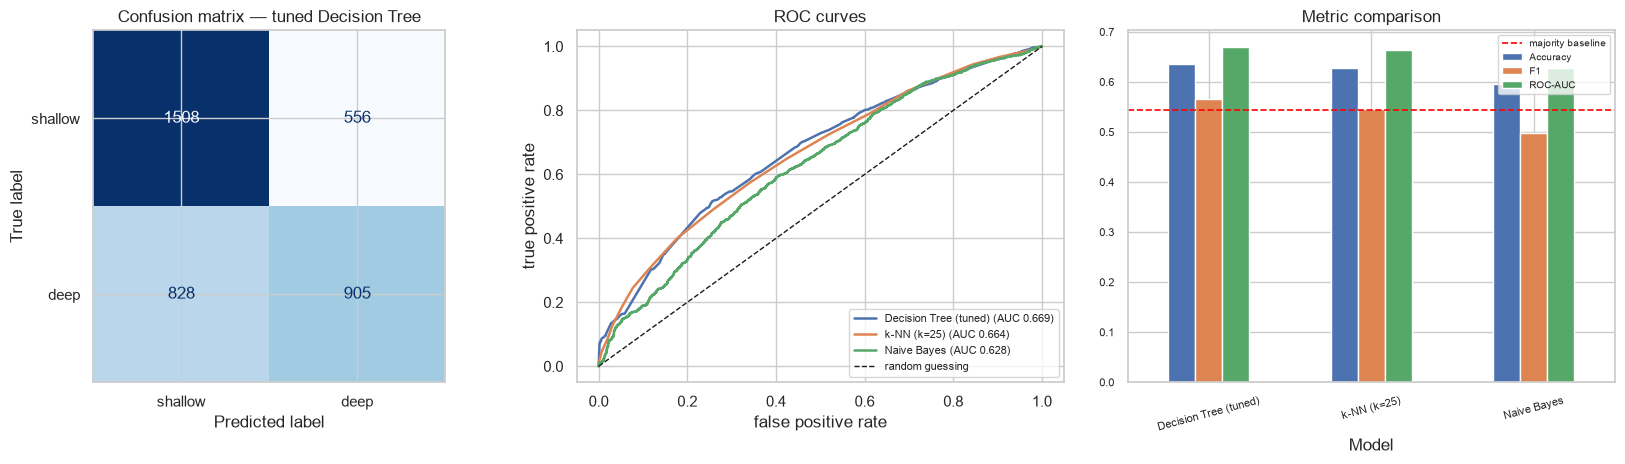

              precision    recall  f1-score   support

     shallow       0.65      0.73      0.69      2064
        deep       0.62      0.52      0.57      1733

    accuracy                           0.64      3797
   macro avg       0.63      0.63      0.63      3797
weighted avg       0.63      0.64      0.63      3797



In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# Confusion matrix for the tuned tree
best_pred = tuned_tree.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=["shallow", "deep"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix — tuned Decision Tree")

# ROC curves for all three
for name, model in final_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1].plot(fpr, tpr, lw=1.8, label=f"{name} (AUC {auc(fpr, tpr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="random guessing")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curves")
axes[1].legend(fontsize=8, loc="lower right")

# Metric comparison
test_results.plot(kind="bar", ax=axes[2], rot=15)
axes[2].axhline(max(y.mean(), 1 - y.mean()), color="red", linestyle="--", lw=1.2,
                label="majority baseline")
axes[2].set_title("Metric comparison")
axes[2].legend(fontsize=7)
axes[2].tick_params(labelsize=8)

plt.tight_layout(); plt.show()

print(classification_report(y_test, best_pred, target_names=["shallow", "deep"]))

### Confusion matrix

The matrix shows where the tuned tree gets things right and wrong. The two error
types are not equally costly in practice:

- **False positives** (predicted deep, actually shallow) — a visitor gets an
  intervention they did not need. Mild cost.
- **False negatives** (predicted shallow, actually deep) — an engaged visitor is
  missed. Higher opportunity cost.

If this were deployed, the decision threshold could be lowered to catch more genuine
deep sessions at the price of more false alarms. The ROC curve shows that trade-off
across every possible threshold, which is why it is more informative here than a
single accuracy number.

## 6. What the tree learned

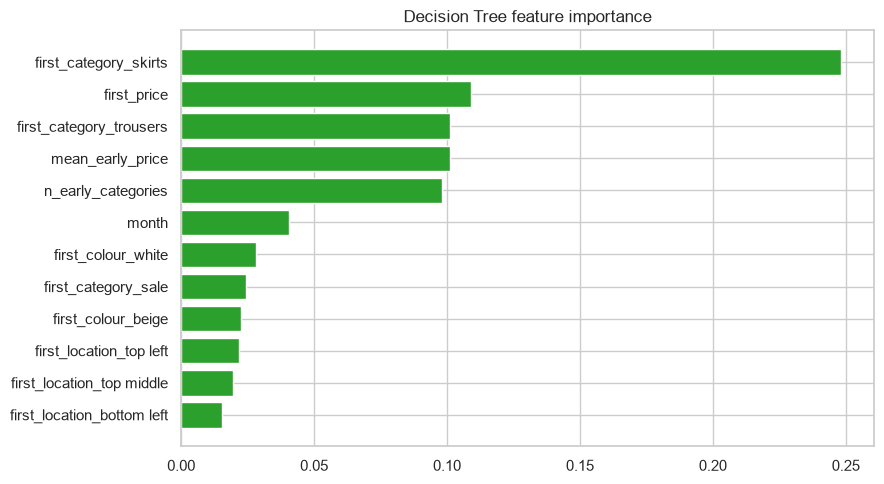

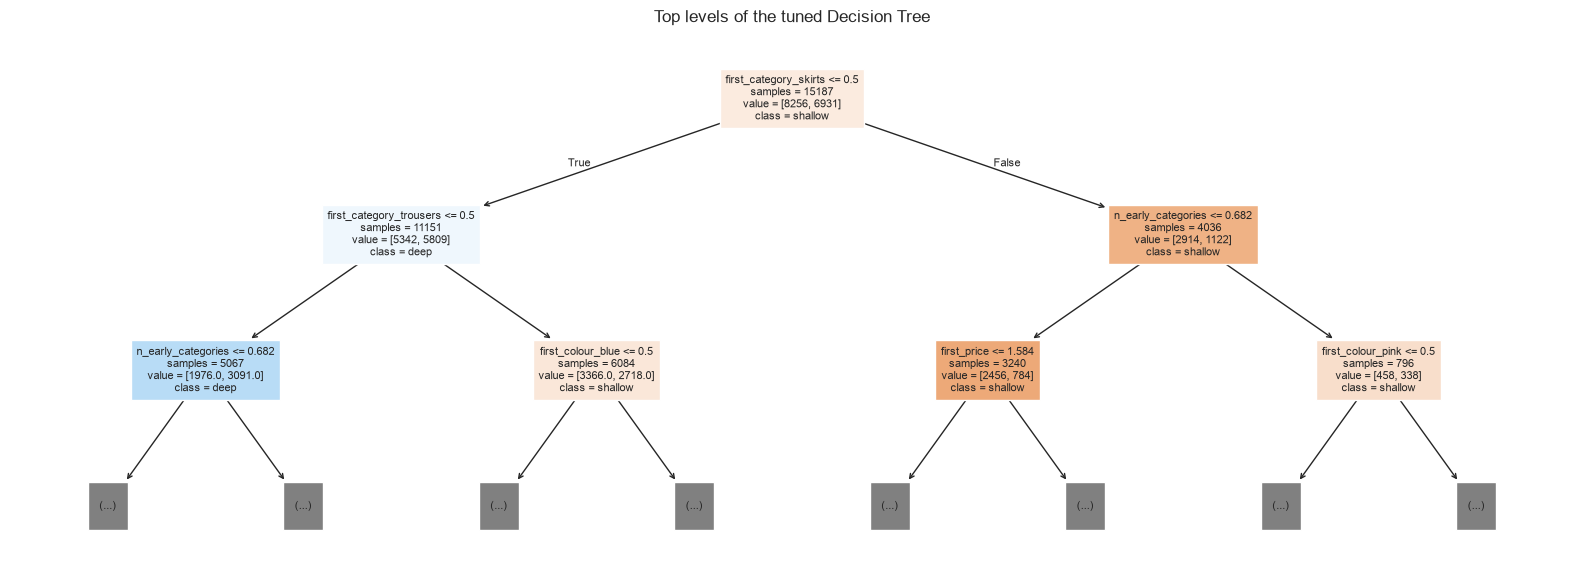

In [9]:
tree = tuned_tree.named_steps["model"]
names = [n.split("__")[-1] for n in tuned_tree.named_steps["prep"].get_feature_names_out()]

imp = pd.Series(tree.feature_importances_, index=names)
imp = imp[imp > 0].sort_values(ascending=False).head(12)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.index, imp.values, color="tab:green")
ax.set_title("Decision Tree feature importance")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(tree, max_depth=2, feature_names=names, class_names=["shallow", "deep"],
          filled=True, fontsize=8, ax=ax, impurity=False)
ax.set_title("Top levels of the tuned Decision Tree")
plt.tight_layout(); plt.show()

# Part B — Clustering

## 7. Finding session types

K-Means groups sessions by behaviour. Features are **standardised first** because
K-Means uses Euclidean distance: without scaling, `mean_price` (range ~18–82) would
dominate `n_categories` (range 1–4) purely because of its units.

`log_n_clicks` is used instead of raw click counts, for the reason established in
Deliverable 1, the raw distribution is heavily right-skewed, and a handful of
195-click sessions would otherwise pull the cluster centres toward themselves.

k=2  inertia=   81852  silhouette=0.3601
k=3  inertia=   66870  silhouette=0.2638
k=4  inertia=   54315  silhouette=0.2721
k=5  inertia=   47708  silhouette=0.2688
k=6  inertia=   43097  silhouette=0.2646
k=7  inertia=   40047  silhouette=0.2537
k=8  inertia=   37626  silhouette=0.2447


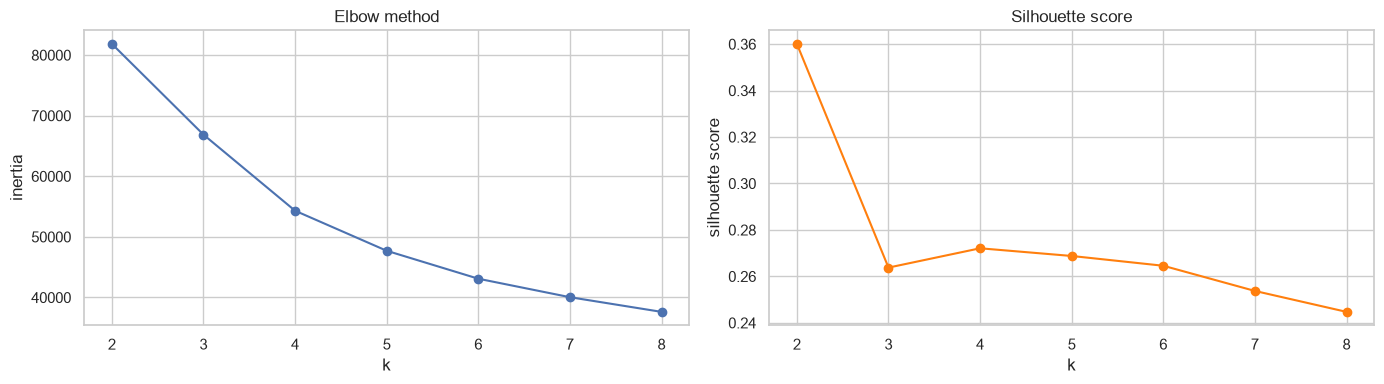

In [10]:
CLUSTER_FEATURES = ["log_n_clicks", "max_page", "n_categories",
                    "n_colours", "mean_price", "price_range"]

X_cluster = StandardScaler().fit_transform(sessions[CLUSTER_FEATURES])

# Silhouette on a sample - it is O(n^2) and would be slow on 24,026 rows
sample = np.random.default_rng(42).choice(len(X_cluster), 5000, replace=False)

inertias, silhouettes, ks = [], [], range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster[sample], km.labels_[sample]))
    print(f"k={k}  inertia={km.inertia_:>8.0f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(ks), inertias, "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow method")
axes[1].plot(list(ks), silhouettes, "o-", color="tab:orange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette score")
plt.tight_layout(); plt.show()

### Choosing k — where the metric and the use case disagree

The silhouette score is highest at **k=2**. But inspecting that solution shows it
splits sessions only into "short" and "long", a distinction already captured by
`n_clicks` alone, so clustering adds nothing.

**k=4 is used instead.** Its silhouette is lower, but it separates sessions on *two*
dimensions — engagement level *and* price level, producing groups that are
distinguishable in ways a single existing column does not already capture.

This is a judgement call and is recorded as one. The silhouette score measures how
cleanly separated clusters are, not how useful they are, and those are not the same
question. Both solutions are profiled below so the trade-off is visible.

In [11]:
for k in [2, 4]:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_cluster)
    sessions[f"cluster_k{k}"] = labels
    profile = sessions.groupby(f"cluster_k{k}").agg(
        n_sessions=("n_clicks", "size"),
        clicks=("n_clicks", "mean"),
        max_page=("max_page", "mean"),
        categories=("n_categories", "mean"),
        colours=("n_colours", "mean"),
        price=("mean_price", "mean"),
        price_range=("price_range", "mean"),
    ).round(1)
    print(f"--- k={k} ---")
    print(profile.to_string())
    print()

sessions["cluster"] = sessions["cluster_k4"]

--- k=2 ---
            n_sessions  clicks  max_page  categories  colours  price  price_range
cluster_k2                                                                       
0                14407     2.6       1.6         1.3      1.9   44.9         11.6
1                 9619    13.3       3.2         2.7      6.0   43.6         35.9

--- k=4 ---
            n_sessions  clicks  max_page  categories  colours  price  price_range
cluster_k4                                                                       
0                 8376     6.1       2.3         1.9      3.7   44.8         28.9
1                 5285    18.0       3.7         3.1      7.4   43.0         39.3
2                 5754     1.8       1.6         1.2      1.5   36.2          4.4
3                 4611     1.9       1.4         1.1      1.5   55.4          8.2



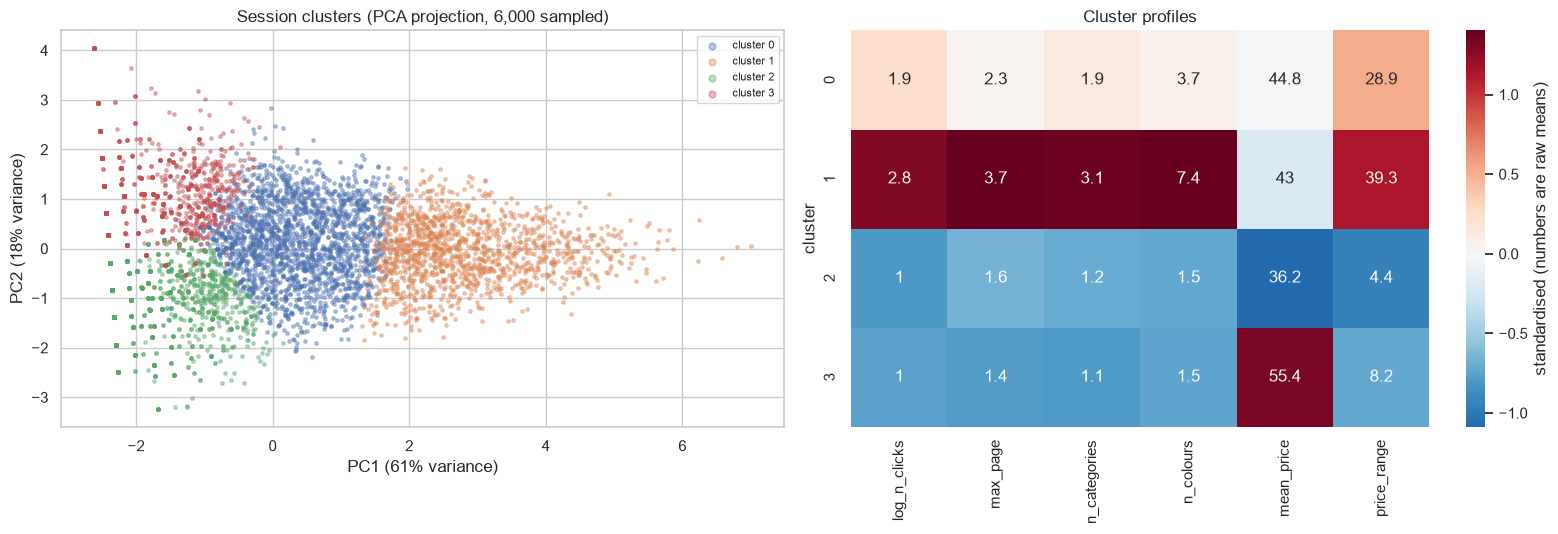

In [12]:
# Visualise the 4 clusters: PCA projection + behavioural profile
pca = PCA(n_components=2)
coords = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sub = np.random.default_rng(0).choice(len(coords), 6000, replace=False)
for cl in sorted(sessions["cluster"].unique()):
    m = sessions["cluster"].values[sub] == cl
    axes[0].scatter(coords[sub][m, 0], coords[sub][m, 1], s=6, alpha=0.4, label=f"cluster {cl}")
axes[0].set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.0f}% variance)")
axes[0].set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.0f}% variance)")
axes[0].set_title("Session clusters (PCA projection, 6,000 sampled)")
axes[0].legend(fontsize=8, markerscale=2)

profile = sessions.groupby("cluster")[CLUSTER_FEATURES].mean()
normed = (profile - profile.mean()) / profile.std()
sns.heatmap(normed, annot=profile.round(1), fmt="g", cmap="RdBu_r", center=0,
            ax=axes[1], cbar_kws={"label": "standardised (numbers are raw means)"})
axes[1].set_title("Cluster profiles")
axes[1].set_ylabel("cluster")

plt.tight_layout(); plt.show()

### The four session types

Reading the profile heatmap, the clusters separate into recognisable shopper
behaviours:

- **Cluster 2 — Budget bouncers** (~5,750 sessions). About 2 clicks, lowest prices
  (~$36), one category. They arrive, look at something cheap, and leave.
- **Cluster 3 — Premium bouncers** (~4,600 sessions). About 2 clicks, highest prices
  (~$55), one category. The same brief visit, but looking at expensive items.
- **Cluster 0 — Moderate browsers** (~8,400 sessions). About 6 clicks across 2
  categories at mid prices. The largest group.
- **Cluster 1 — Deep explorers** (~5,300 sessions). About 18 clicks, 3 categories, 7
  colours, and the widest price range. Highly engaged.

The most useful finding here is that the two brief-visit groups are **not the same
segment**. Both leave after roughly two clicks, but one is looking at the cheapest
items and the other at the most expensive. A retention effort treating them
identically would misread half of them, and note that a k=2 solution would have
merged exactly these two groups, which is the concrete reason k=4 was chosen.

# Part C — Association Rule Mining

## 8. Session baskets

Each session is treated as a transaction containing the attributes of everything
browsed. Association rules then reveal which attributes are viewed together.

This dataset needs no artificial discretisation for this step, sessions are already
baskets.

In [13]:
# Build baskets from attributes that vary within a session
clicks["price_band"] = pd.qcut(clicks["price"], 4,
                               labels=["budget", "mid-low", "mid-high", "premium"])
clicks["item_category"] = "cat=" + clicks["main_category"]
clicks["item_price"] = "price=" + clicks["price_band"].astype(str)

long = pd.concat([
    clicks[["session_id", "item_category"]].rename(columns={"item_category": "item"}),
    clicks[["session_id", "item_price"]].rename(columns={"item_price": "item"}),
])
baskets = long.groupby("session_id")["item"].apply(lambda s: sorted(set(s))).tolist()

encoder = TransactionEncoder()
basket_df = pd.DataFrame(encoder.fit(baskets).transform(baskets), columns=encoder.columns_)

print(f"Transactions: {len(baskets):,}")
print(f"Distinct items: {basket_df.shape[1]}")
print(f"Mean items per session: {np.mean([len(b) for b in baskets]):.1f}")

Transactions: 24,026
Distinct items: 8
Mean items per session: 4.3


In [14]:
frequent = apriori(basket_df, min_support=0.03, use_colnames=True, max_len=3)
rules = association_rules(frequent, metric="lift", min_threshold=1.05)
rules = rules[rules["confidence"] >= 0.4].sort_values("lift", ascending=False)

print(f"Frequent itemsets: {len(frequent)}   Rules (lift>1.05, conf>=0.4): {len(rules)}\n")

display_rules = rules.head(10).copy()
display_rules["antecedents"] = display_rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
display_rules["consequents"] = display_rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
display_rules[["antecedents", "consequents", "support", "confidence", "lift"]].round(3)

Frequent itemsets: 92   Rules (lift>1.05, conf>=0.4): 274



                      antecedents                   consequents  support  \
84        cat=blouses, cat=skirts                price=mid-high    0.186   
129                   cat=blouses  price=budget, price=mid-high    0.271   
124  price=budget, price=mid-high                   cat=blouses    0.271   
53          cat=blouses, cat=sale                price=mid-high    0.162   
106  cat=trousers, price=mid-high                   cat=blouses    0.205   
111                   cat=blouses  cat=trousers, price=mid-high    0.205   
110                price=mid-high     cat=blouses, cat=trousers    0.205   
107     cat=blouses, cat=trousers                price=mid-high    0.205   
149    cat=blouses, price=premium                price=mid-high    0.228   
152                price=mid-high    cat=blouses, price=premium    0.228   

     confidence   lift  
84        0.894  1.786  
129       0.608  1.756  
124       0.784  1.756  
53        0.857  1.713  
106       0.755  1.692  
111       0.4

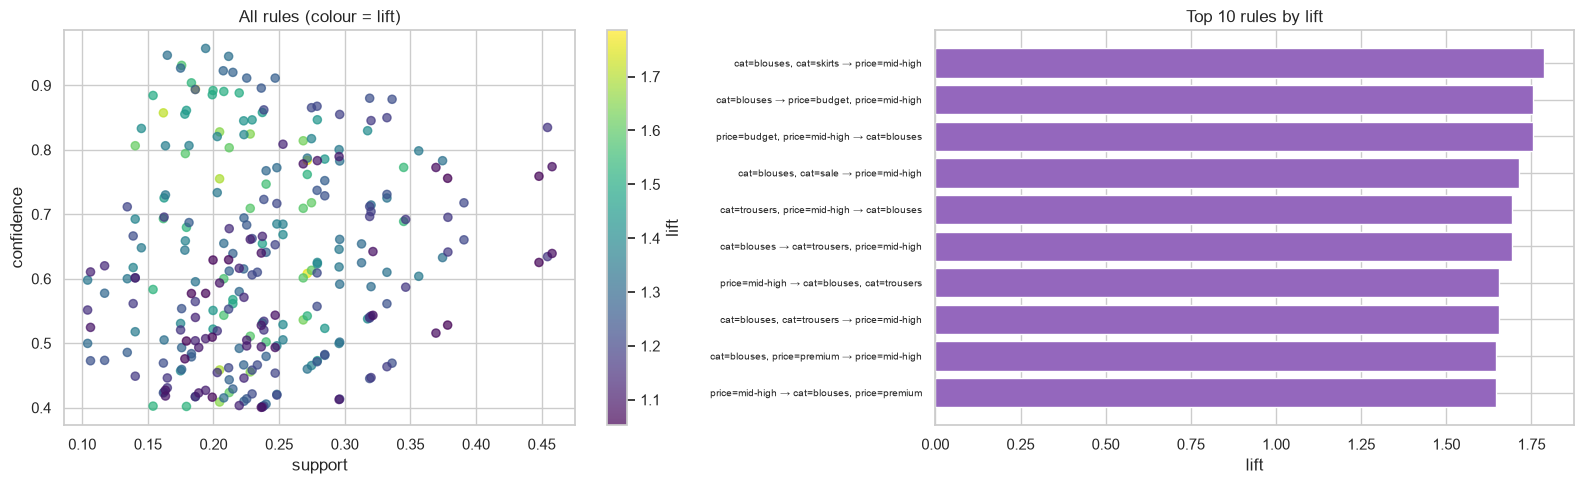

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(rules["support"], rules["confidence"],
                c=rules["lift"], cmap="viridis", s=35, alpha=0.7)
axes[0].set_xlabel("support"); axes[0].set_ylabel("confidence")
axes[0].set_title("All rules (colour = lift)")
plt.colorbar(axes[0].collections[0], ax=axes[0], label="lift")

top = rules.head(10)
labels = [f"{', '.join(sorted(a))} → {', '.join(sorted(c))}"
          for a, c in zip(top["antecedents"], top["consequents"])]
axes[1].barh(range(len(top)), top["lift"].values[::-1], color="tab:purple")
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels(labels[::-1], fontsize=7)
axes[1].set_xlabel("lift")
axes[1].set_title("Top 10 rules by lift")

plt.tight_layout(); plt.show()

### What the rules say

**Lift** is the key metric: a lift of 1.8 means the combination occurs 80% more often
than it would if the two items were unrelated. Support says how common the pattern
is; confidence says how reliable it is once the antecedent appears.

Two patterns stand out:

**1. Shoppers browse across categories, not within one.** Rules linking blouses with
trousers and skirts appear repeatedly at lift around 1.65–1.79. Visitors are not
looking for "a skirt", they are assembling outfits, moving between garment types in
a single session.

**2. Shoppers mix price tiers within one session.** Budget items co-occur with
mid-high items at lift 1.76. The same visitor looks at both cheap and expensive
products, which argues against treating "budget shopper" and "premium shopper" as
fixed customer types, at least within a session.

## 9. Insights and Real-World Applications

### Classification — predicting engagement early

The tuned Decision Tree beats the majority baseline, though modestly. Two clicks is
genuinely little information, and the honest conclusion is that early behaviour
carries *some* signal about eventual engagement, not that engagement is
straightforwardly predictable.

**Practical use:** a model like this could drive a real-time decision, offering
assistance, a recommendation, or a promotion to visitors predicted to disengage. The
threshold matters more than the accuracy: since missing an engaged visitor costs more
than an unnecessary prompt, the model should be tuned toward recall rather than
overall accuracy.

**Limitation:** predicting depth is not predicting purchase. This dataset has no
sales, so a "deep" session is engaged, not necessarily valuable.

### Clustering — four session types

The most actionable result is the split between **budget bouncers** and **premium
bouncers**. Both leave after about two clicks, so a bounce-rate report would merge
them, but they are looking at opposite ends of the price range and plausibly need
different treatment, price reassurance for one, quality or delivery information for
the other.

**Deep explorers** (~5,300 sessions) are the natural audience for recommendation
features, since they already browse widely across categories and colours.

### Pattern mining — cross-category browsing

The strongest behavioural pattern is that shoppers move **between** garment
categories within a session, at lift 1.65–1.79.

**Practical use:** this argues for cross-category recommendations ("complete the
outfit") over more-of-the-same suggestions, and for merchandising that places
complementary garment types near each other rather than strictly segregating
categories.